# 02 - Análisis Exploratorio de Datos (EDA)
## Sistema de Predicción Temprana de Plagas - Sierra del Patlachique

**Objetivo:** Entender la naturaleza y características de cada variable

**Responsabilidades:**
- Estadísticas descriptivas por variable
- Análisis de distribuciones
- Patrones temporales y estacionalidad
- Correlaciones entre variables
- Identificar anomalías (sin corregir)
- Generar visualizaciones
- Documentar hallazgos en reporte

**NO hacer aquí:**
- Limpiar o imputar datos
- Calcular indicadores de riesgo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Estilos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Librerías cargadas")

Librerías cargadas


In [2]:
# Cargar datos crudos del notebook anterior
df = pd.read_csv("../data/raw/datos_patlachique_raw.csv", index_col='fecha', parse_dates=True)

print(f"Datos cargados: {df.shape[0]} registros, {df.shape[1]} variables")
print(f"  Período: {df.index.min().date()} a {df.index.max().date()}")

Datos cargados: 817 registros, 4 variables
  Período: 2024-01-01 a 2026-03-27


## 1. TEMPERATURA MEDIA (°C)

In [3]:
print("\n" + "="*60)
print("VARIABLE: TEMPERATURA MEDIA (temp_media_C)")
print("="*60)
print("\nESTADÍSTICAS DESCRIPTIVAS:")

temp = df['temp_media_C']

stats_dict = {
    'Media': temp.mean(),
    'Mediana': temp.median(),
    'Desv. Estándar': temp.std(),
    'Mínimo': temp.min(),
    'Q1 (25%)': temp.quantile(0.25),
    'Q3 (75%)': temp.quantile(0.75),
    'Máximo': temp.max(),
    'Rango': temp.max() - temp.min(),
    'IQR': temp.quantile(0.75) - temp.quantile(0.25),
    'Curtosis': stats.kurtosis(temp.dropna()),
    'Asimetría': stats.skew(temp.dropna())
}

for stat, value in stats_dict.items():
    print(f"  {stat:.<25} {value:>10.2f}")

print("\nINTERPRETACIÓN:")
print("\t- En el Patlachique (2,500 msnm), la temperatura promedio es templada (~14°C)")
print("\t- Oscilación térmica de ~20°C entre mínimo y máximo (característica de montaña)")
print("\t- Distribución ligeramente sesgada = períodos más fríos que cálidos")


VARIABLE: TEMPERATURA MEDIA (temp_media_C)

ESTADÍSTICAS DESCRIPTIVAS:
  Media....................      10.86
  Mediana..................      14.43
  Desv. Estándar...........      61.41
  Mínimo...................    -999.00
  Q1 (25%).................      12.63
  Q3 (75%).................      16.07
  Máximo...................      22.72
  Rango....................    1021.72
  IQR......................       3.44
  Curtosis.................     266.22
  Asimetría................     -16.36

INTERPRETACIÓN:
	- En el Patlachique (2,500 msnm), la temperatura promedio es templada (~14°C)
	- Oscilación térmica de ~20°C entre mínimo y máximo (característica de montaña)
	- Distribución ligeramente sesgada = períodos más fríos que cálidos


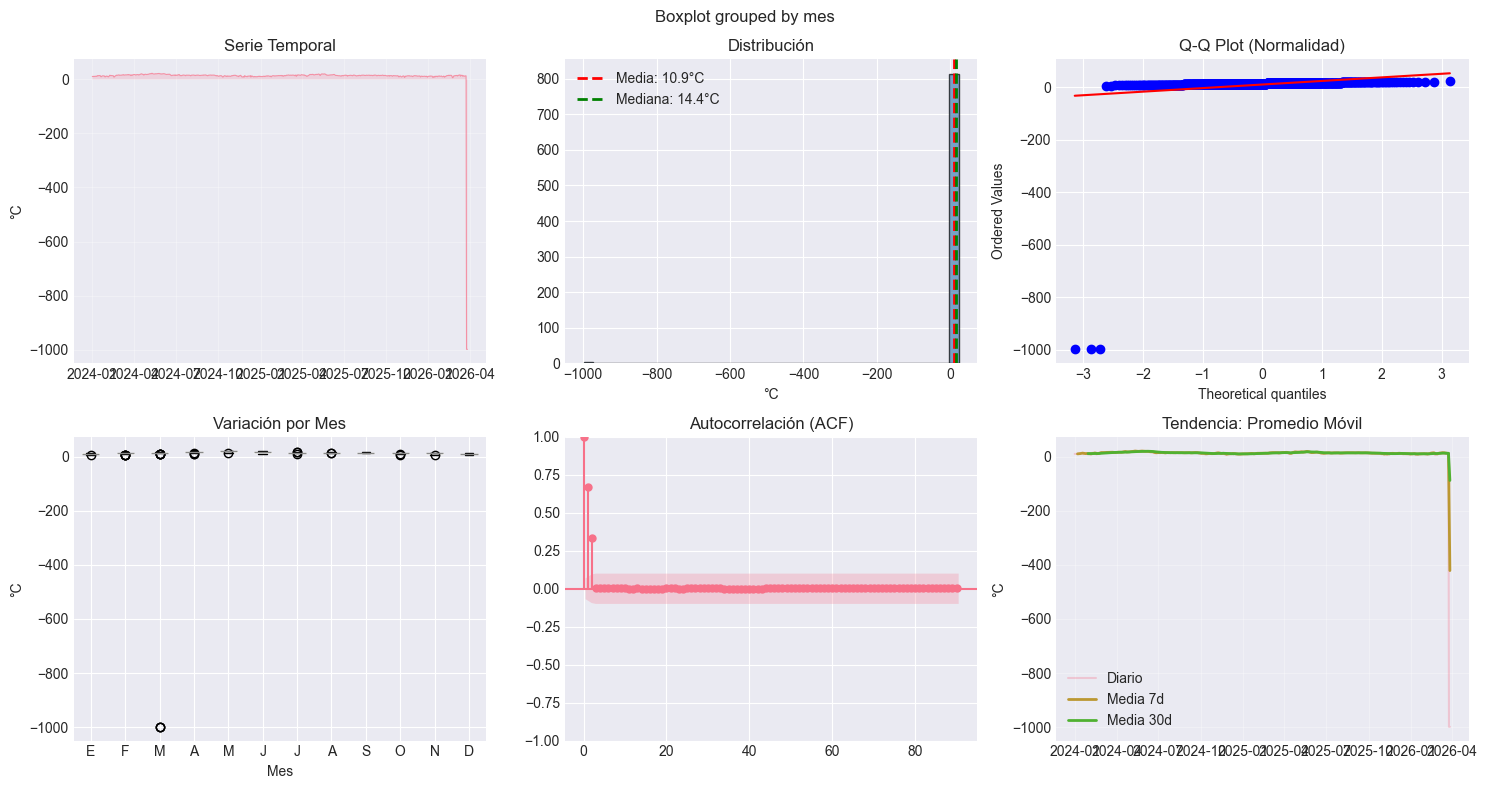


Gráficas guardadas en reports/temperatura_eda.png


In [4]:
# Panel de gráficas para temperatura
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('TEMPERATURA MEDIA: Análisis Completo', fontsize=14, fontweight='bold')

# 1. Serie temporal
axes[0, 0].plot(df.index, temp, linewidth=0.8, alpha=0.7)
axes[0, 0].fill_between(df.index, temp, alpha=0.2)
axes[0, 0].set_title('Serie Temporal')
axes[0, 0].set_ylabel('°C')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma
axes[0, 1].hist(temp, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(temp.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {temp.mean():.1f}°C')
axes[0, 1].axvline(temp.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {temp.median():.1f}°C')
axes[0, 1].set_title('Distribución')
axes[0, 1].set_xlabel('°C')
axes[0, 1].legend()

# 3. Q-Q Plot (normalidad)
stats.probplot(temp, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Normalidad)')

# 4. Box plot por mes
df['mes'] = df.index.month
df.boxplot(column='temp_media_C', by='mes', ax=axes[1, 0])
axes[1, 0].set_title('Variación por Mes')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('°C')
plt.sca(axes[1, 0])
plt.xticks(range(1, 13), ['E','F','M','A','M','J','J','A','S','O','N','D'])

# 5. ACF (Autocorrelación)
plot_acf(temp.dropna(), lags=90, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelación (ACF)')

# 6. Promedio móvil
axes[1, 2].plot(df.index, temp, alpha=0.3, label='Diario')
axes[1, 2].plot(df.index, temp.rolling(window=7).mean(), linewidth=2, label='Media 7d')
axes[1, 2].plot(df.index, temp.rolling(window=30).mean(), linewidth=2, label='Media 30d')
axes[1, 2].set_title('Tendencia: Promedio Móvil')
axes[1, 2].set_ylabel('°C')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/reports/temperatura_eda.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráficas guardadas en reports/temperatura_eda.png")

## 2. LLUVIA (mm)

In [5]:
print("\n" + "="*60)
print("VARIABLE: LLUVIA (lluvia_mm)")
print("="*60)
print("\nESTADÍSTICAS DESCRIPTIVAS:")

lluvia = df['lluvia_mm']

stats_dict = {
    'Media': lluvia.mean(),
    'Mediana': lluvia.median(),
    'Desv. Estándar': lluvia.std(),
    'Mínimo': lluvia.min(),
    'Q1 (25%)': lluvia.quantile(0.25),
    'Q3 (75%)': lluvia.quantile(0.75),
    'Máximo': lluvia.max(),
    'Rango': lluvia.max() - lluvia.min(),
    'Días sin lluvia': (lluvia == 0).sum(),
    '% Días sin lluvia': (lluvia == 0).sum() / len(lluvia) * 100,
    'Lluvia total anual': lluvia.sum()
}

for stat, value in stats_dict.items():
    if '%' in stat:
        print(f"  {stat:.<25} {value:>10.1f}%")
    else:
        print(f"  {stat:.<25} {value:>10.2f}")

print("\nINTERPRETACIÓN:")
print("\t- Lluvia muy variable: fuerte estacionalidad (sequía vs. lluvia)")
print("\t- Muchos días sin lluvia (distribución muy sesgada a la derecha)")
print("\t- Lluvia total anual ~700-900mm típico de montaña subtropical")
print("\t- Eventos puntuales intensos durante temporada de lluvia")


VARIABLE: LLUVIA (lluvia_mm)

ESTADÍSTICAS DESCRIPTIVAS:
  Media....................      -1.06
  Mediana..................       0.47
  Desv. Estándar...........      60.77
  Mínimo...................    -999.00
  Q1 (25%).................        0.0%
  Q3 (75%).................        3.7%
  Máximo...................      35.93
  Rango....................    1034.93
  Días sin lluvia..........     171.00
  % Días sin lluvia........       20.9%
  Lluvia total anual.......    -869.40

INTERPRETACIÓN:
	- Lluvia muy variable: fuerte estacionalidad (sequía vs. lluvia)
	- Muchos días sin lluvia (distribución muy sesgada a la derecha)
	- Lluvia total anual ~700-900mm típico de montaña subtropical
	- Eventos puntuales intensos durante temporada de lluvia


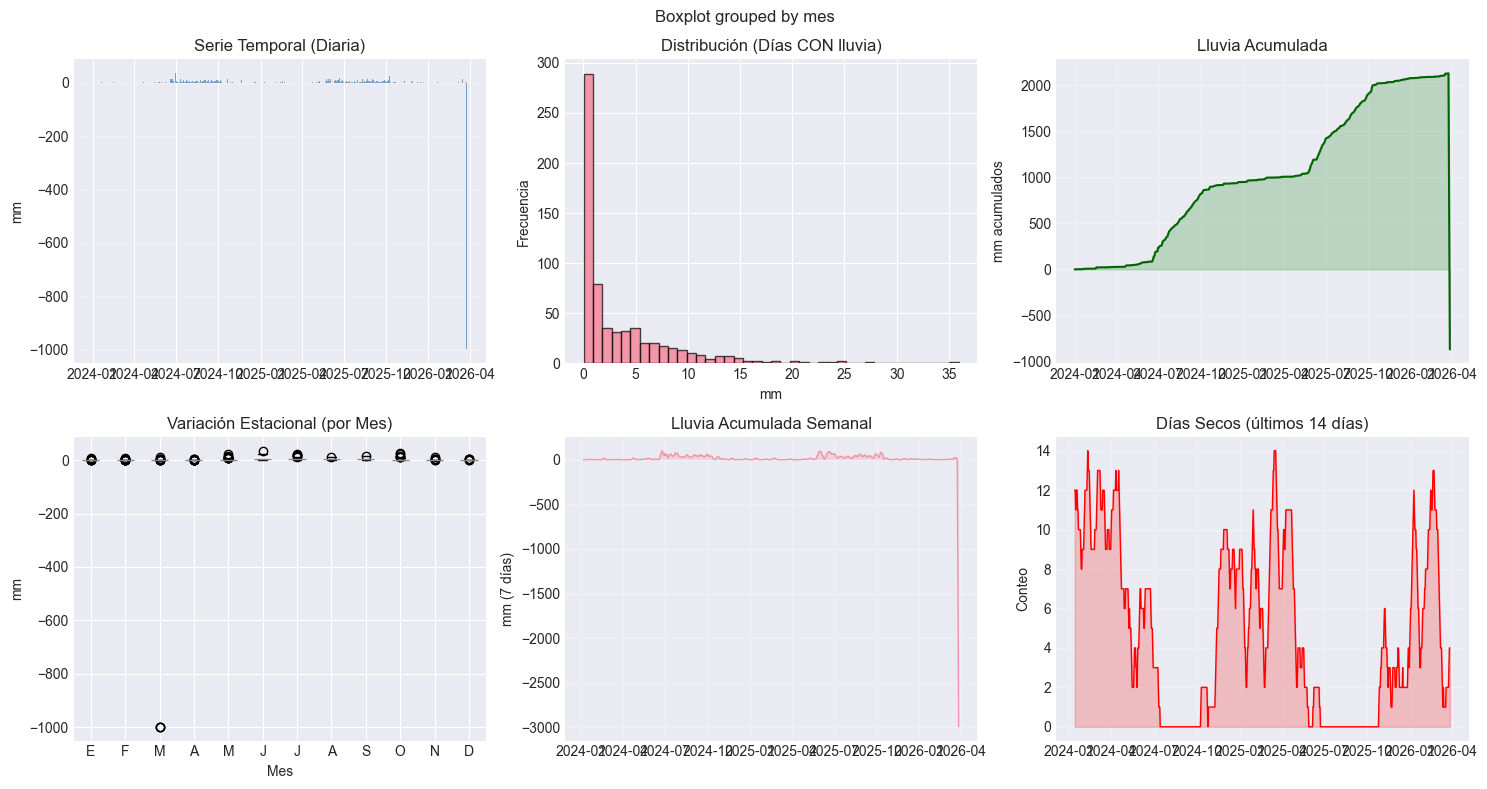


Gráficas guardadas en reports/lluvia_eda.png


In [6]:
# Panel de gráficas para lluvia
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('LLUVIA: Análisis Completo', fontsize=14, fontweight='bold')

# 1. Serie temporal
axes[0, 0].bar(df.index, lluvia, width=1, alpha=0.7, color='steelblue')
axes[0, 0].set_title('Serie Temporal (Diaria)')
axes[0, 0].set_ylabel('mm')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Histograma (escala logarítmica porque está muy sesgada)
axes[0, 1].hist(lluvia[lluvia > 0], bins=40, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución (Días CON lluvia)')
axes[0, 1].set_xlabel('mm')
axes[0, 1].set_ylabel('Frecuencia')

# 3. Lluvia acumulada
lluvia_acumulada = lluvia.cumsum()
axes[0, 2].plot(df.index, lluvia_acumulada, linewidth=1.5, color='darkgreen')
axes[0, 2].fill_between(df.index, lluvia_acumulada, alpha=0.2, color='green')
axes[0, 2].set_title('Lluvia Acumulada')
axes[0, 2].set_ylabel('mm acumulados')
axes[0, 2].grid(True, alpha=0.3)

# 4. Box plot por mes (IMPORTANTE para estacionalidad)
df.boxplot(column='lluvia_mm', by='mes', ax=axes[1, 0])
axes[1, 0].set_title('Variación Estacional (por Mes)')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('mm')
plt.sca(axes[1, 0])
plt.xticks(range(1, 13), ['E','F','M','A','M','J','J','A','S','O','N','D'])

# 5. Lluvia acumulada por 7 días
lluvia_7d = lluvia.rolling(window=7).sum()
axes[1, 1].plot(df.index, lluvia_7d, linewidth=1, alpha=0.7, label='7 días')
axes[1, 1].fill_between(df.index, lluvia_7d, alpha=0.2)
axes[1, 1].set_title('Lluvia Acumulada Semanal')
axes[1, 1].set_ylabel('mm (7 días)')
axes[1, 1].grid(True, alpha=0.3)

# 6. Días secos consecutivos
dias_secos = (lluvia < 0.1).astype(int)
dias_secos_14d = dias_secos.rolling(window=14).sum()
axes[1, 2].plot(df.index, dias_secos_14d, linewidth=1, color='red')
axes[1, 2].fill_between(df.index, dias_secos_14d, alpha=0.2, color='red')
axes[1, 2].set_title('Días Secos (últimos 14 días)')
axes[1, 2].set_ylabel('Conteo')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/reports/lluvia_eda.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráficas guardadas en reports/lluvia_eda.png")

## 3. HUMEDAD DEL SUELO (fracción 0-1)

In [7]:
print("\n" + "="*60)
print("VARIABLE: HUMEDAD DEL SUELO (humedad_suelo_frac)")
print("="*60)
print("\nESTADÍSTICAS DESCRIPTIVAS:")

hs = df['humedad_suelo_frac']

stats_dict = {
    'Media': hs.mean(),
    'Mediana': hs.median(),
    'Desv. Estándar': hs.std(),
    'Mínimo': hs.min(),
    'Q1 (25%)': hs.quantile(0.25),
    'Q3 (75%)': hs.quantile(0.75),
    'Máximo': hs.max(),
    'Rango': hs.max() - hs.min(),
}

for stat, value in stats_dict.items():
    print(f"\t{stat:.<25} {value:>10.3f}")

print("\nINTERPRETACIÓN:")
print("\t- Escala 0-1: 0=suelo seco, 1=suelo saturado")
print("\t- Patlachique: Vertisoles arcillosos retienen humedad MUCHO TIEMPO")
print("\t- Cambios lentos (no es como lluvia diaria)")
print("\t- LAG importante: lluvia → humedad suelo (retraso de días/semanas)")


VARIABLE: HUMEDAD DEL SUELO (humedad_suelo_frac)

ESTADÍSTICAS DESCRIPTIVAS:
	Media....................     -3.150
	Mediana..................      0.510
	Desv. Estándar...........     60.494
	Mínimo...................   -999.000
	Q1 (25%).................      0.390
	Q3 (75%).................      0.670
	Máximo...................      0.820
	Rango....................    999.820

INTERPRETACIÓN:
	- Escala 0-1: 0=suelo seco, 1=suelo saturado
	- Patlachique: Vertisoles arcillosos retienen humedad MUCHO TIEMPO
	- Cambios lentos (no es como lluvia diaria)
	- LAG importante: lluvia → humedad suelo (retraso de días/semanas)


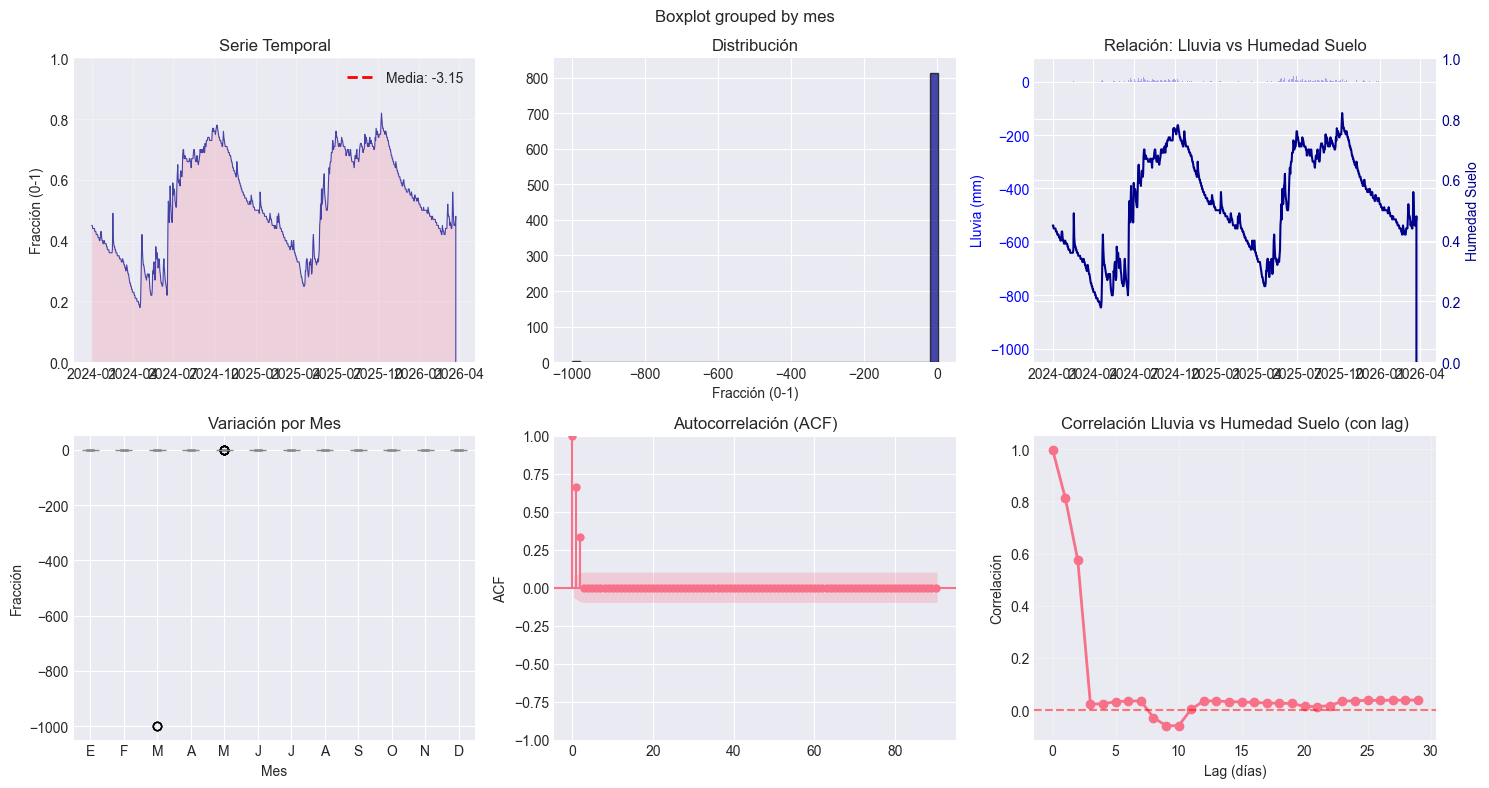


Gráficas guardadas en reports/humedad_suelo_eda.png


In [8]:
# Panel de gráficas para humedad del suelo
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('HUMEDAD DEL SUELO: Análisis Completo', fontsize=14, fontweight='bold')

# 1. Serie temporal
axes[0, 0].plot(df.index, hs, linewidth=0.8, alpha=0.7, color='darkblue')
axes[0, 0].fill_between(df.index, hs, alpha=0.2)
axes[0, 0].axhline(y=hs.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {hs.mean():.2f}')
axes[0, 0].set_title('Serie Temporal')
axes[0, 0].set_ylabel('Fracción (0-1)')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma
axes[0, 1].hist(hs, bins=50, edgecolor='black', alpha=0.7, color='darkblue')
axes[0, 1].set_title('Distribución')
axes[0, 1].set_xlabel('Fracción (0-1)')

# 3. Comparación: lluvia vs humedad suelo
ax_temp = axes[0, 2]
ax_temp.bar(df.index, lluvia, alpha=0.3, label='Lluvia (mm)', color='blue')
ax_temp.set_ylabel('Lluvia (mm)', color='blue')
ax_temp.tick_params(axis='y', labelcolor='blue')

ax_temp2 = ax_temp.twinx()
ax_temp2.plot(df.index, hs, color='darkblue', linewidth=1.5, label='Humedad Suelo')
ax_temp2.set_ylabel('Humedad Suelo', color='darkblue')
ax_temp2.tick_params(axis='y', labelcolor='darkblue')
ax_temp2.set_ylim([0, 1])
ax_temp.set_title('Relación: Lluvia vs Humedad Suelo')

# 4. Box plot por mes
df.boxplot(column='humedad_suelo_frac', by='mes', ax=axes[1, 0])
axes[1, 0].set_title('Variación por Mes')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Fracción')
plt.sca(axes[1, 0])
plt.xticks(range(1, 13), ['E','F','M','A','M','J','J','A','S','O','N','D'])

# 5. ACF (Autocorrelación)
plot_acf(hs.dropna(), lags=90, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelación (ACF)')
axes[1, 1].set_ylabel('ACF')

# 6. Lag entre lluvia y humedad (correlación con rezagos)
correlaciones = []
lags = range(0, 30)
for lag in lags:
    corr = lluvia.corr(hs.shift(-lag))
    correlaciones.append(corr)

axes[1, 2].plot(lags, correlaciones, marker='o', linewidth=2)
axes[1, 2].set_title('Correlación Lluvia vs Humedad Suelo (con lag)')
axes[1, 2].set_xlabel('Lag (días)')
axes[1, 2].set_ylabel('Correlación')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../data/reports/humedad_suelo_eda.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráficas guardadas en reports/humedad_suelo_eda.png")

## 4. HUMEDAD RELATIVA (%)

In [9]:
print("\n" + "="*60)
print("VARIABLE: HUMEDAD RELATIVA (humedad_relativa_pct)")
print("="*60)
print("\nESTADÍSTICAS DESCRIPTIVAS:")

hr = df['humedad_relativa_pct']

stats_dict = {
    'Media': hr.mean(),
    'Mediana': hr.median(),
    'Desv. Estándar': hr.std(),
    'Mínimo': hr.min(),
    'Q1 (25%)': hr.quantile(0.25),
    'Q3 (75%)': hr.quantile(0.75),
    'Máximo': hr.max(),
    'Rango': hr.max() - hr.min(),
}

for stat, value in stats_dict.items():
    print(f"\t{stat:.<25} {value:>10.2f}")

print("\n🔍 INTERPRETACIÓN:")
print("\t- Escala 0-100%: 0=aire seco, 100=saturado")
print("\t- En montaña, oscilación diaria típica (baja día, sube noche)")
print("\t- Relación inversa con temperatura (aire caliente absorbe más humedad)")
print("\t- ALERTA: Baja humedad relativa (<60-70%) = aire seco = RIESGO para pulgones")


VARIABLE: HUMEDAD RELATIVA (humedad_relativa_pct)

ESTADÍSTICAS DESCRIPTIVAS:
	Media....................      60.24
	Mediana..................      68.44
	Desv. Estándar...........      66.65
	Mínimo...................    -999.00
	Q1 (25%).................      49.24
	Q3 (75%).................      79.06
	Máximo...................      92.61
	Rango....................    1091.61

🔍 INTERPRETACIÓN:
	- Escala 0-100%: 0=aire seco, 100=saturado
	- En montaña, oscilación diaria típica (baja día, sube noche)
	- Relación inversa con temperatura (aire caliente absorbe más humedad)
	- ALERTA: Baja humedad relativa (<60-70%) = aire seco = RIESGO para pulgones


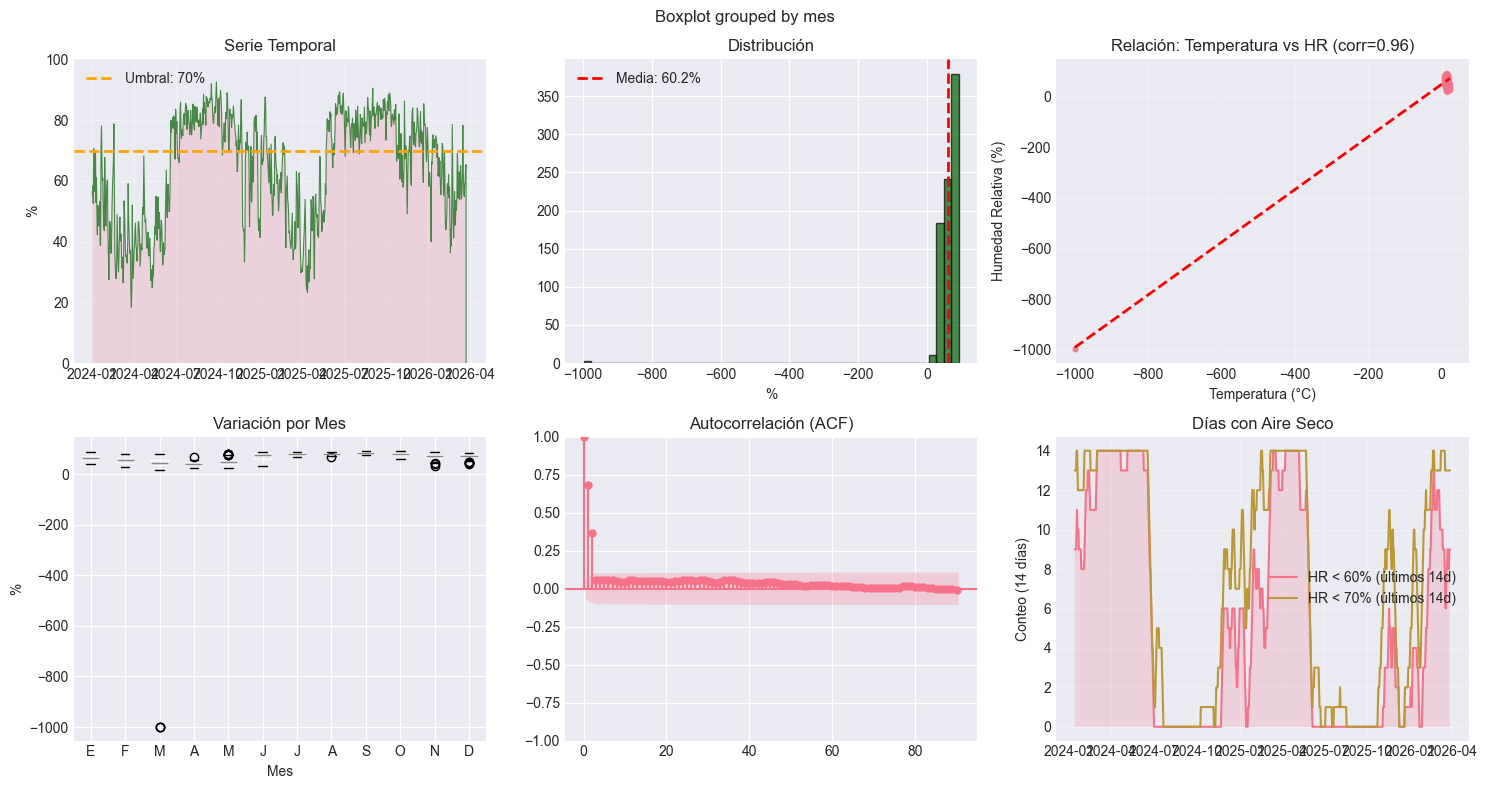


Gráficas guardadas en reports/humedad_relativa_eda.png


In [10]:
# Panel de gráficas para humedad relativa
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('HUMEDAD RELATIVA: Análisis Completo', fontsize=14, fontweight='bold')

# 1. Serie temporal
axes[0, 0].plot(df.index, hr, linewidth=0.8, alpha=0.7, color='darkgreen')
axes[0, 0].fill_between(df.index, hr, alpha=0.2)
axes[0, 0].axhline(y=70, color='orange', linestyle='--', linewidth=2, label='Umbral: 70%')
axes[0, 0].set_title('Serie Temporal')
axes[0, 0].set_ylabel('%')
axes[0, 0].set_ylim([0, 100])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma
axes[0, 1].hist(hr, bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
axes[0, 1].axvline(hr.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {hr.mean():.1f}%')
axes[0, 1].set_title('Distribución')
axes[0, 1].set_xlabel('%')
axes[0, 1].legend()

# 3. Relación inversa: Temperatura vs Humedad Relativa
axes[0, 2].scatter(temp, hr, alpha=0.4, s=10)
z = np.polyfit(temp, hr, 1)
p = np.poly1d(z)
axes[0, 2].plot(temp.sort_values(), p(temp.sort_values()), "r--", linewidth=2)
corr_temp_hr = temp.corr(hr)
axes[0, 2].set_title(f'Relación: Temperatura vs HR (corr={corr_temp_hr:.2f})')
axes[0, 2].set_xlabel('Temperatura (°C)')
axes[0, 2].set_ylabel('Humedad Relativa (%)')
axes[0, 2].grid(True, alpha=0.3)

# 4. Box plot por mes
df.boxplot(column='humedad_relativa_pct', by='mes', ax=axes[1, 0])
axes[1, 0].set_title('Variación por Mes')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('%')
plt.sca(axes[1, 0])
plt.xticks(range(1, 13), ['E','F','M','A','M','J','J','A','S','O','N','D'])

# 5. ACF
plot_acf(hr.dropna(), lags=90, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelación (ACF)')

# 6. Días con aire seco (<60%, <70%, <80%)
dias_muy_seco = (hr < 60).rolling(window=14).sum()
dias_seco = (hr < 70).rolling(window=14).sum()

axes[1, 2].plot(df.index, dias_muy_seco, label='HR < 60% (últimos 14d)', linewidth=1.5)
axes[1, 2].plot(df.index, dias_seco, label='HR < 70% (últimos 14d)', linewidth=1.5)
axes[1, 2].fill_between(df.index, dias_muy_seco, alpha=0.2)
axes[1, 2].set_title('Días con Aire Seco')
axes[1, 2].set_ylabel('Conteo (14 días)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/reports/humedad_relativa_eda.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráficas guardadas en reports/humedad_relativa_eda.png")

## 5. CORRELACIONES ENTRE TODAS LAS VARIABLES


CORRELACIONES ENTRE VARIABLES

Matriz de Correlación de Pearson:
                      temp_media_C  lluvia_mm  humedad_suelo_frac  \
temp_media_C                 1.000      0.997               0.999   
lluvia_mm                    0.997      1.000               0.998   
humedad_suelo_frac           0.999      0.998               1.000   
humedad_relativa_pct         0.960      0.973               0.966   

                      humedad_relativa_pct  
temp_media_C                         0.960  
lluvia_mm                            0.973  
humedad_suelo_frac                   0.966  
humedad_relativa_pct                 1.000  


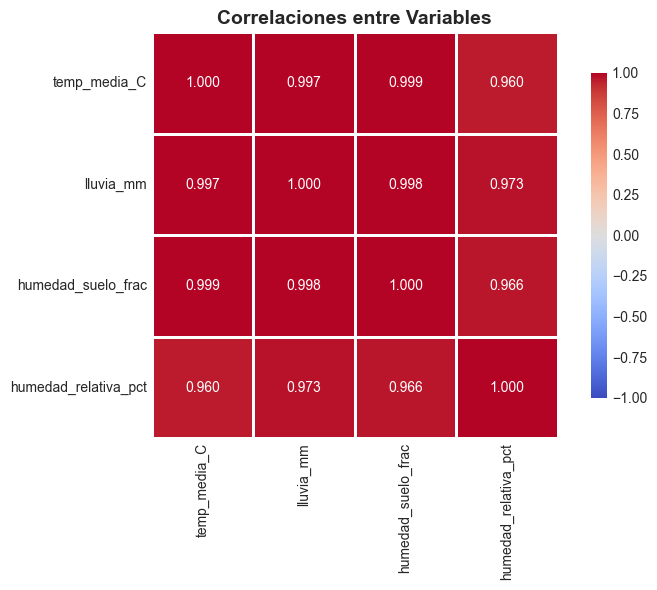


Gráfica guardada en reports/correlaciones_heatmap.png

INTERPRETACIÓN:
  - Temperatura vs Humedad Relativa: Correlación negativa (esperada)
  - Lluvia vs Humedad Suelo: Correlación positiva (lógica)
  - Lluvia vs Humedad Relativa: Positiva (lluvia aumenta HR)


In [11]:
print("\n" + "="*60)
print("CORRELACIONES ENTRE VARIABLES")
print("="*60)

# Calcular matriz de correlación
corr_matrix = df[['temp_media_C', 'lluvia_mm', 'humedad_suelo_frac', 'humedad_relativa_pct']].corr()
print("\nMatriz de Correlación de Pearson:")
print(corr_matrix.round(3))

# Crear heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlaciones entre Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/reports/correlaciones_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfica guardada en reports/correlaciones_heatmap.png")

print("\nINTERPRETACIÓN:")
print("  - Temperatura vs Humedad Relativa: Correlación negativa (esperada)")
print("  - Lluvia vs Humedad Suelo: Correlación positiva (lógica)")
print("  - Lluvia vs Humedad Relativa: Positiva (lluvia aumenta HR)")

## 6. RESUMEN Y CONCLUSIONES

In [12]:
print("\n" + "="*70)
print("RESUMEN DE ANÁLISIS EXPLORATORIO")
print("="*70)

resumen = """
TEMPERATURA MEDIA (temp_media_C)
   • Rango: {:.1f}°C - {:.1f}°C (oscilación = {:.1f}°C)
   • Promedio: {:.1f}°C
   • Patrón: Variación estacional clara (sequía=frío, lluvia=templado)
   • Anomalías: Verificar si hay temperaturas > 45°C o < -10°C
   • Tipo distribución: Ligeramente sesgada a la izquierda

LLUVIA (lluvia_mm)
   • Rango: {:.1f} - {:.1f} mm/día
   • Promedio: {:.2f} mm/día
   • Total anual: {:.1f} mm
   • Días sin lluvia: {} ({:.1f}%)
   • Patrón: Muy sesgada a la derecha (muchos ceros, pocos eventos intensos)
   • Estacionalidad: Sequía (ene-mayo), Lluvia (jun-oct)
   • Anomalías: Verificar si hay lluvia negativa

HUMEDAD DEL SUELO (humedad_suelo_frac)
   • Rango: {:.3f} - {:.3f}
   • Promedio: {:.3f}
   • Patrón: CAMBIOS LENTOS (Vertisoles arcillosos retienen agua)
   • Lag importante: Lluvia → Humedad suelo (2-7 días)
   • Crítico para chapulín: Humedad alta → eclosión
   • Anomalías: Verificar si hay valores > 1 o < 0

HUMEDAD RELATIVA (humedad_relativa_pct)
   • Rango: {:.1f}% - {:.1f}%
   • Promedio: {:.1f}%
   • Patrón: Inverso a temperatura (aire caliente = más seco)
   • Umbral crítico: < 70% = aire seco = RIESGO pulgones y ácaros
   • Anomalías: Verificar si hay valores > 100% o < 0%

RELACIONES CLAVE:
   • Temperatura ↔ Humedad Relativa: FUERTE correlación negativa
   • Lluvia ↔ Humedad Suelo: Correlación positiva con LAG
   • Lluvia ↔ Humedad Relativa: Positiva (lluvia aumenta HR)
""".format(
    temp.min(), temp.max(), temp.max() - temp.min(), temp.mean(),
    lluvia.min(), lluvia.max(), lluvia.mean(), lluvia.sum(),
    (lluvia == 0).sum(), (lluvia == 0).sum() / len(lluvia) * 100,
    hs.min(), hs.max(), hs.mean(),
    hr.min(), hr.max(), hr.mean()
)

print(resumen)

print("\n" + "="*70)
print("Próximo paso: Notebook 03 - Data Cleaning")
print("\tBasaremos la limpieza en los hallazgos del EDA anterior")
print("="*70)


RESUMEN DE ANÁLISIS EXPLORATORIO

TEMPERATURA MEDIA (temp_media_C)
   • Rango: -999.0°C - 22.7°C (oscilación = 1021.7°C)
   • Promedio: 10.9°C
   • Patrón: Variación estacional clara (sequía=frío, lluvia=templado)
   • Anomalías: Verificar si hay temperaturas > 45°C o < -10°C
   • Tipo distribución: Ligeramente sesgada a la izquierda

LLUVIA (lluvia_mm)
   • Rango: -999.0 - 35.9 mm/día
   • Promedio: -1.06 mm/día
   • Total anual: -869.4 mm
   • Días sin lluvia: 171 (20.9%)
   • Patrón: Muy sesgada a la derecha (muchos ceros, pocos eventos intensos)
   • Estacionalidad: Sequía (ene-mayo), Lluvia (jun-oct)
   • Anomalías: Verificar si hay lluvia negativa

HUMEDAD DEL SUELO (humedad_suelo_frac)
   • Rango: -999.000 - 0.820
   • Promedio: -3.150
   • Patrón: CAMBIOS LENTOS (Vertisoles arcillosos retienen agua)
   • Lag importante: Lluvia → Humedad suelo (2-7 días)
   • Crítico para chapulín: Humedad alta → eclosión
   • Anomalías: Verificar si hay valores > 1 o < 0

HUMEDAD RELATIVA (hum